In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:

# --- 1. Load Data ---
data_file = Path('../data/T100_domestic/processed/final_enriched_t100_data.parquet')
print(f"--- Loading data from {data_file} ---")
df = pd.read_parquet(data_file)

--- Loading data from ../data/T100_domestic/processed/final_enriched_t100_data.parquet ---


In [3]:
# there are many examples where ORIGIN == DEST or DISTANCE == 0. Origin = destination is understandable,
# but there are many cases where DISTANCE = 0 but ORIGIN != DEST, which seems like a data error.
df = df[(df.ORIGIN != df.DEST) & (df.DISTANCE != 0)].copy()
df['year_month'] = df['YEAR'].astype(str) + '-' + df['MONTH'].astype(str).str.zfill(2)

In [4]:
df.columns

Index(['PASSENGERS', 'FREIGHT', 'MAIL', 'DISTANCE', 'UNIQUE_CARRIER',
       'AIRLINE_ID', 'UNIQUE_CARRIER_NAME', 'UNIQUE_CARRIER_ENTITY', 'REGION',
       'CARRIER', 'CARRIER_NAME', 'CARRIER_GROUP', 'CARRIER_GROUP_NEW',
       'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN_CITY_MARKET_ID',
       'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'ORIGIN_STATE_FIPS',
       'ORIGIN_STATE_NM', 'ORIGIN_COUNTRY', 'ORIGIN_COUNTRY_NAME',
       'ORIGIN_WAC', 'DEST_AIRPORT_ID', 'DEST_AIRPORT_SEQ_ID',
       'DEST_CITY_MARKET_ID', 'DEST', 'DEST_CITY_NAME', 'DEST_STATE_ABR',
       'DEST_STATE_FIPS', 'DEST_STATE_NM', 'DEST_COUNTRY', 'DEST_COUNTRY_NAME',
       'DEST_WAC', 'YEAR', 'QUARTER', 'MONTH', 'DISTANCE_GROUP', 'CLASS',
       'DATA_SOURCE', 'File_name', 'date', 'origin_airport_name',
       'origin_airport_type', 'origin_country_name', 'origin_continent',
       'origin_iso_country', 'dest_airport_name', 'dest_airport_type',
       'dest_country_name', 'dest_continent', 'dest_iso

<Axes: xlabel='year_month'>

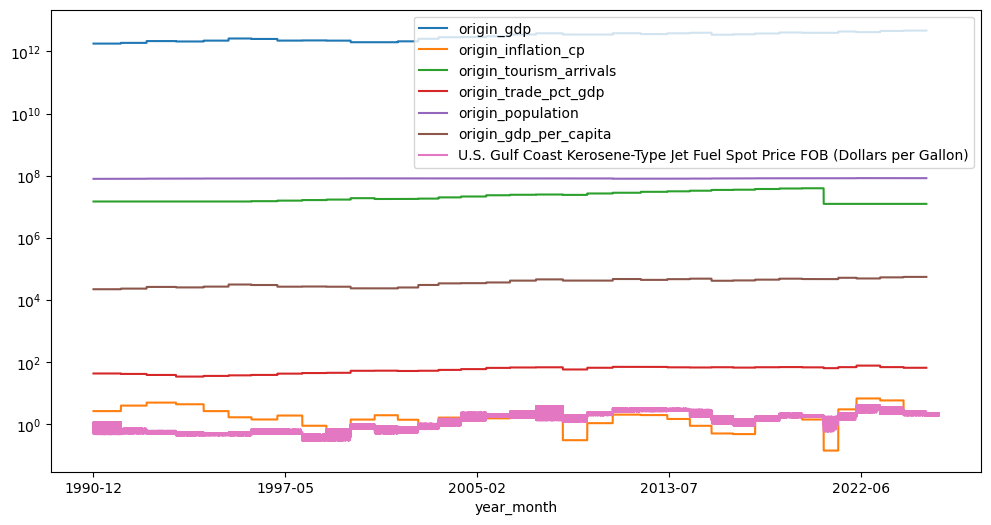

In [36]:
df.loc[df.origin_country_name == 'Germany'].plot(x='year_month', y=[
    'origin_gdp',            # Wealthier countries should visit more
    'origin_inflation_cp',
    'origin_tourism_arrivals',
    'origin_trade_pct_gdp',
    'origin_population',     # Bigger countries should visit more
    'origin_gdp_per_capita', # Wealth per person might influence travel propensity
    'U.S. Gulf Coast Kerosene-Type Jet Fuel Spot Price FOB (Dollars per Gallon)' # Cost of travel
], kind='line', logy=True, figsize=(12, 6))

In [42]:
df.loc[(df.origin_country_name == 'Germany') & (df.YEAR == 2019)][['MONTH', 'U.S. Gulf Coast Kerosene-Type Jet Fuel Spot Price FOB (Dollars per Gallon)' ]].drop_duplicates()

,MONTH,U.S. Gulf Coast Kerosene-Type Jet Fuel Spot Price FOB (Dollars per Gallon)
8178221,4,1.977
8178232,8,1.800
8178248,6,1.817
8178292,3,1.902
8178295,7,1.913
8178303,5,1.972
8178307,1,1.784
8183634,11,1.824
8187916,2,1.914
8192341,9,1.874


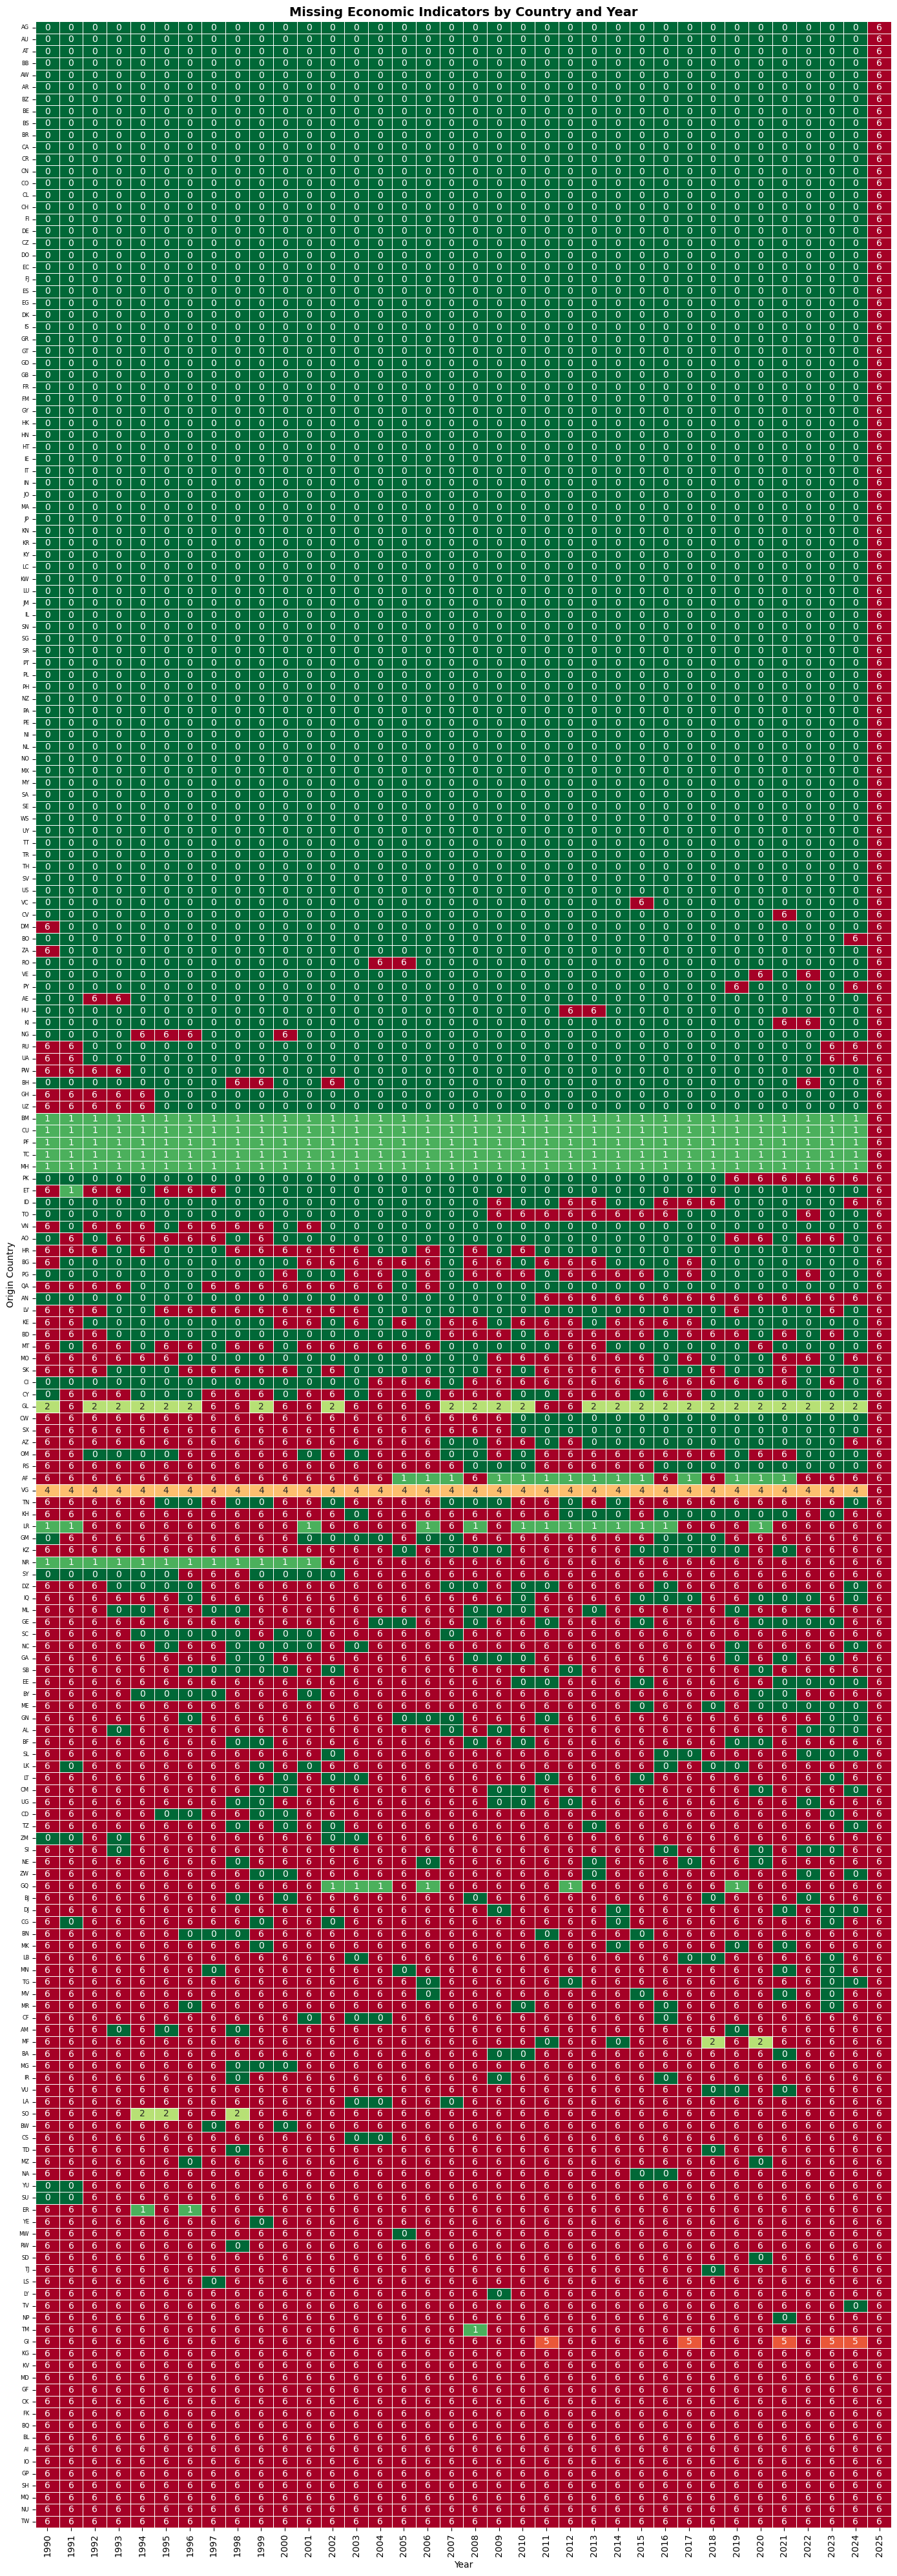

In [16]:
# Create a dataframe with unique country-year combinations and their economic data
country_year_data = df.groupby(['ORIGIN_COUNTRY', 'YEAR'], observed=False).agg({
    'origin_inflation_cp': 'first',
    'origin_gdp': 'first',
    'origin_gdp_per_capita': 'first',
    'origin_population': 'first',
    'origin_tourism_arrivals': 'first',
    'origin_trade_pct_gdp': 'first'
}).reset_index()

# Count missing values for each indicator
country_year_data['missing_count'] = country_year_data[
    ['origin_inflation_cp', 'origin_gdp', 'origin_gdp_per_capita', 
     'origin_population', 'origin_tourism_arrivals', 'origin_trade_pct_gdp']
].isna().sum(axis=1)

# Create pivot table: rows=country, columns=year, values=missing_count
missing_pivot = country_year_data.pivot_table(
    index='ORIGIN_COUNTRY',
    columns='YEAR',
    values='missing_count',
    aggfunc='first',  # Each country-year combo appears only once
    observed=True
)

# Sort rows by total missing count (best to worst data completeness)
missing_pivot['total_missing'] = missing_pivot.sum(axis=1)
missing_pivot = missing_pivot.sort_values('total_missing').drop('total_missing', axis=1)

fig, ax = plt.subplots(figsize=(14, 40))

sns.heatmap(
    missing_pivot,
    cmap='RdYlGn_r',
    vmin=0,
    vmax=int(missing_pivot.max().max()),
    cbar = False,
    linewidths=0.5,
    annot=True,
    ax=ax
)
ax.set_title('Missing Economic Indicators by Country and Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Origin Country')

ax.set_yticklabels(ax.get_yticklabels(), fontsize=6, rotation=0)
fig.tight_layout()
plt.show()

In [17]:
df_inbound = df[df['Travel_type'] == 'Inbound International'].copy()

<Axes: xlabel='DISTANCE', ylabel='PASSENGERS'>

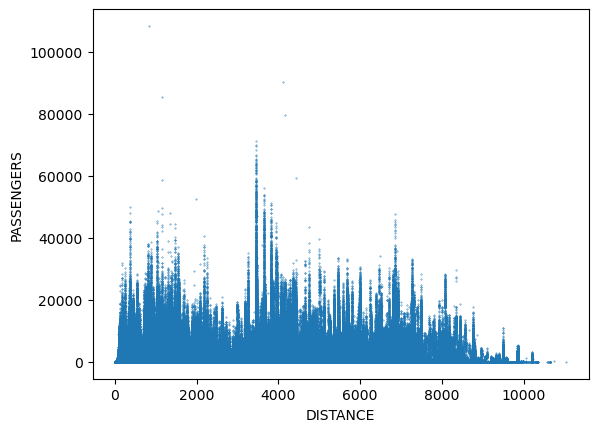

In [18]:
df_inbound.plot(x='DISTANCE', y='PASSENGERS', kind='scatter', s=0.1)

In [20]:
# --- 3. Select Features ---
# We pick features that plausibly drive demand for coming TO the US.
target_col = 'PASSENGERS'

numerical_features = [
    'DISTANCE',
    'origin_gdp',            # Wealthier countries should visit more
    'origin_inflation_cp',
    'origin_tourism_arrivals',
    'origin_trade_pct_gdp',
    'origin_population',     # Bigger countries should visit more
    'origin_gdp_per_capita', # Wealth per person might influence travel propensity
    #'U.S. Gulf Coast Kerosene-Type Jet Fuel Spot Price FOB (Dollars per Gallon)' # Cost of travel
]

# We treat MONTH as categorical to capture seasonality (Summer peaks vs Winter lows)
# We treat origin_continent as categorical to capture regional trends
categorical_features = ['origin_continent', 'year_month']
#categorical_features = []

# Create modeling dataframe
cols_to_keep = numerical_features + categorical_features + [target_col]
df_model = df_inbound[cols_to_keep].dropna()

In [21]:
df_model = df_model.groupby(numerical_features + categorical_features)[target_col].sum().reset_index().copy()

In [22]:
print(f'Number of rows: {len(df_model)}')
df_model.describe(include='all')

Number of rows: 644255


,DISTANCE,origin_gdp,origin_inflation_cp,origin_tourism_arrivals,origin_trade_pct_gdp,origin_population,origin_gdp_per_capita,origin_continent,year_month,PASSENGERS
count,644255.0,6.442550e+05,644255.000000,6.442550e+05,644255.000000,6.442550e+05,644255.000000,644255,644255,644255.0
unique,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,6,420,<NA>
top,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,NA,2024-07,<NA>
freq,<NA>,NaN,NaN,NaN,NaN,NaN,NaN,333240,1870,<NA>
mean,2944.814233,1.190456e+12,9.830997,3.235745e+07,58.478009,8.285726e+07,23795.639353,NaN,NaN,3999.077701
std,2208.163391,1.841860e+12,93.349454,3.941712e+07,43.982986,2.077090e+08,20387.220522,NaN,NaN,7409.760389
min,2.0,3.653429e+07,-12.296984,3.600000e+03,7.805932,9.646000e+03,96.319224,NaN,NaN,0.0
25%,1200.0,8.464433e+10,1.649431,2.880000e+06,38.418543,8.606326e+06,7135.222733,NaN,NaN,39.0
50%,2086.0,6.340000e+11,2.912135,1.620800e+07,50.323884,3.570450e+07,20186.798878,NaN,NaN,1091.0
75%,4428.0,1.574199e+12,5.291226,4.489600e+07,63.405075,8.604481e+07,39169.359570,NaN,NaN,4937.0


In [23]:
df_model

,DISTANCE,origin_gdp,origin_inflation_cp,origin_tourism_arrivals,origin_trade_pct_gdp,origin_population,origin_gdp_per_capita,origin_continent,year_month,PASSENGERS
0,2,1.466465e+12,7.896276,51128000.0,82.103704,128613117.0,11402.141037,NA,2022-10,0
1,2,1.793799e+12,5.527961,51128000.0,67.704414,129739759.0,13826.130657,NA,2023-02,3
2,12,6.312494e+11,16.585617,99869000.0,44.748560,97115707.0,6499.971830,NA,1999-05,0
3,12,7.420613e+11,9.491561,105673000.0,46.604099,98625552.0,7524.027138,NA,2000-01,0
4,12,7.420613e+11,9.491561,105673000.0,46.604099,98625552.0,7524.027138,NA,2000-10,0
...,...,...,...,...,...,...,...,...,...,...
644250,10641,2.347725e+11,6.757313,4467000.0,45.279586,225048008.0,1043.210584,AS,2003-10,0
644251,10641,2.347725e+11,6.757313,4467000.0,45.279586,225048008.0,1043.210584,AS,2003-11,0
644252,10641,2.347725e+11,6.757313,4467000.0,45.279586,225048008.0,1043.210584,AS,2003-12,0
644253,10749,8.916338e+11,6.869537,5358000.0,21.999726,184688101.0,4827.781731,SA,2005-09,167


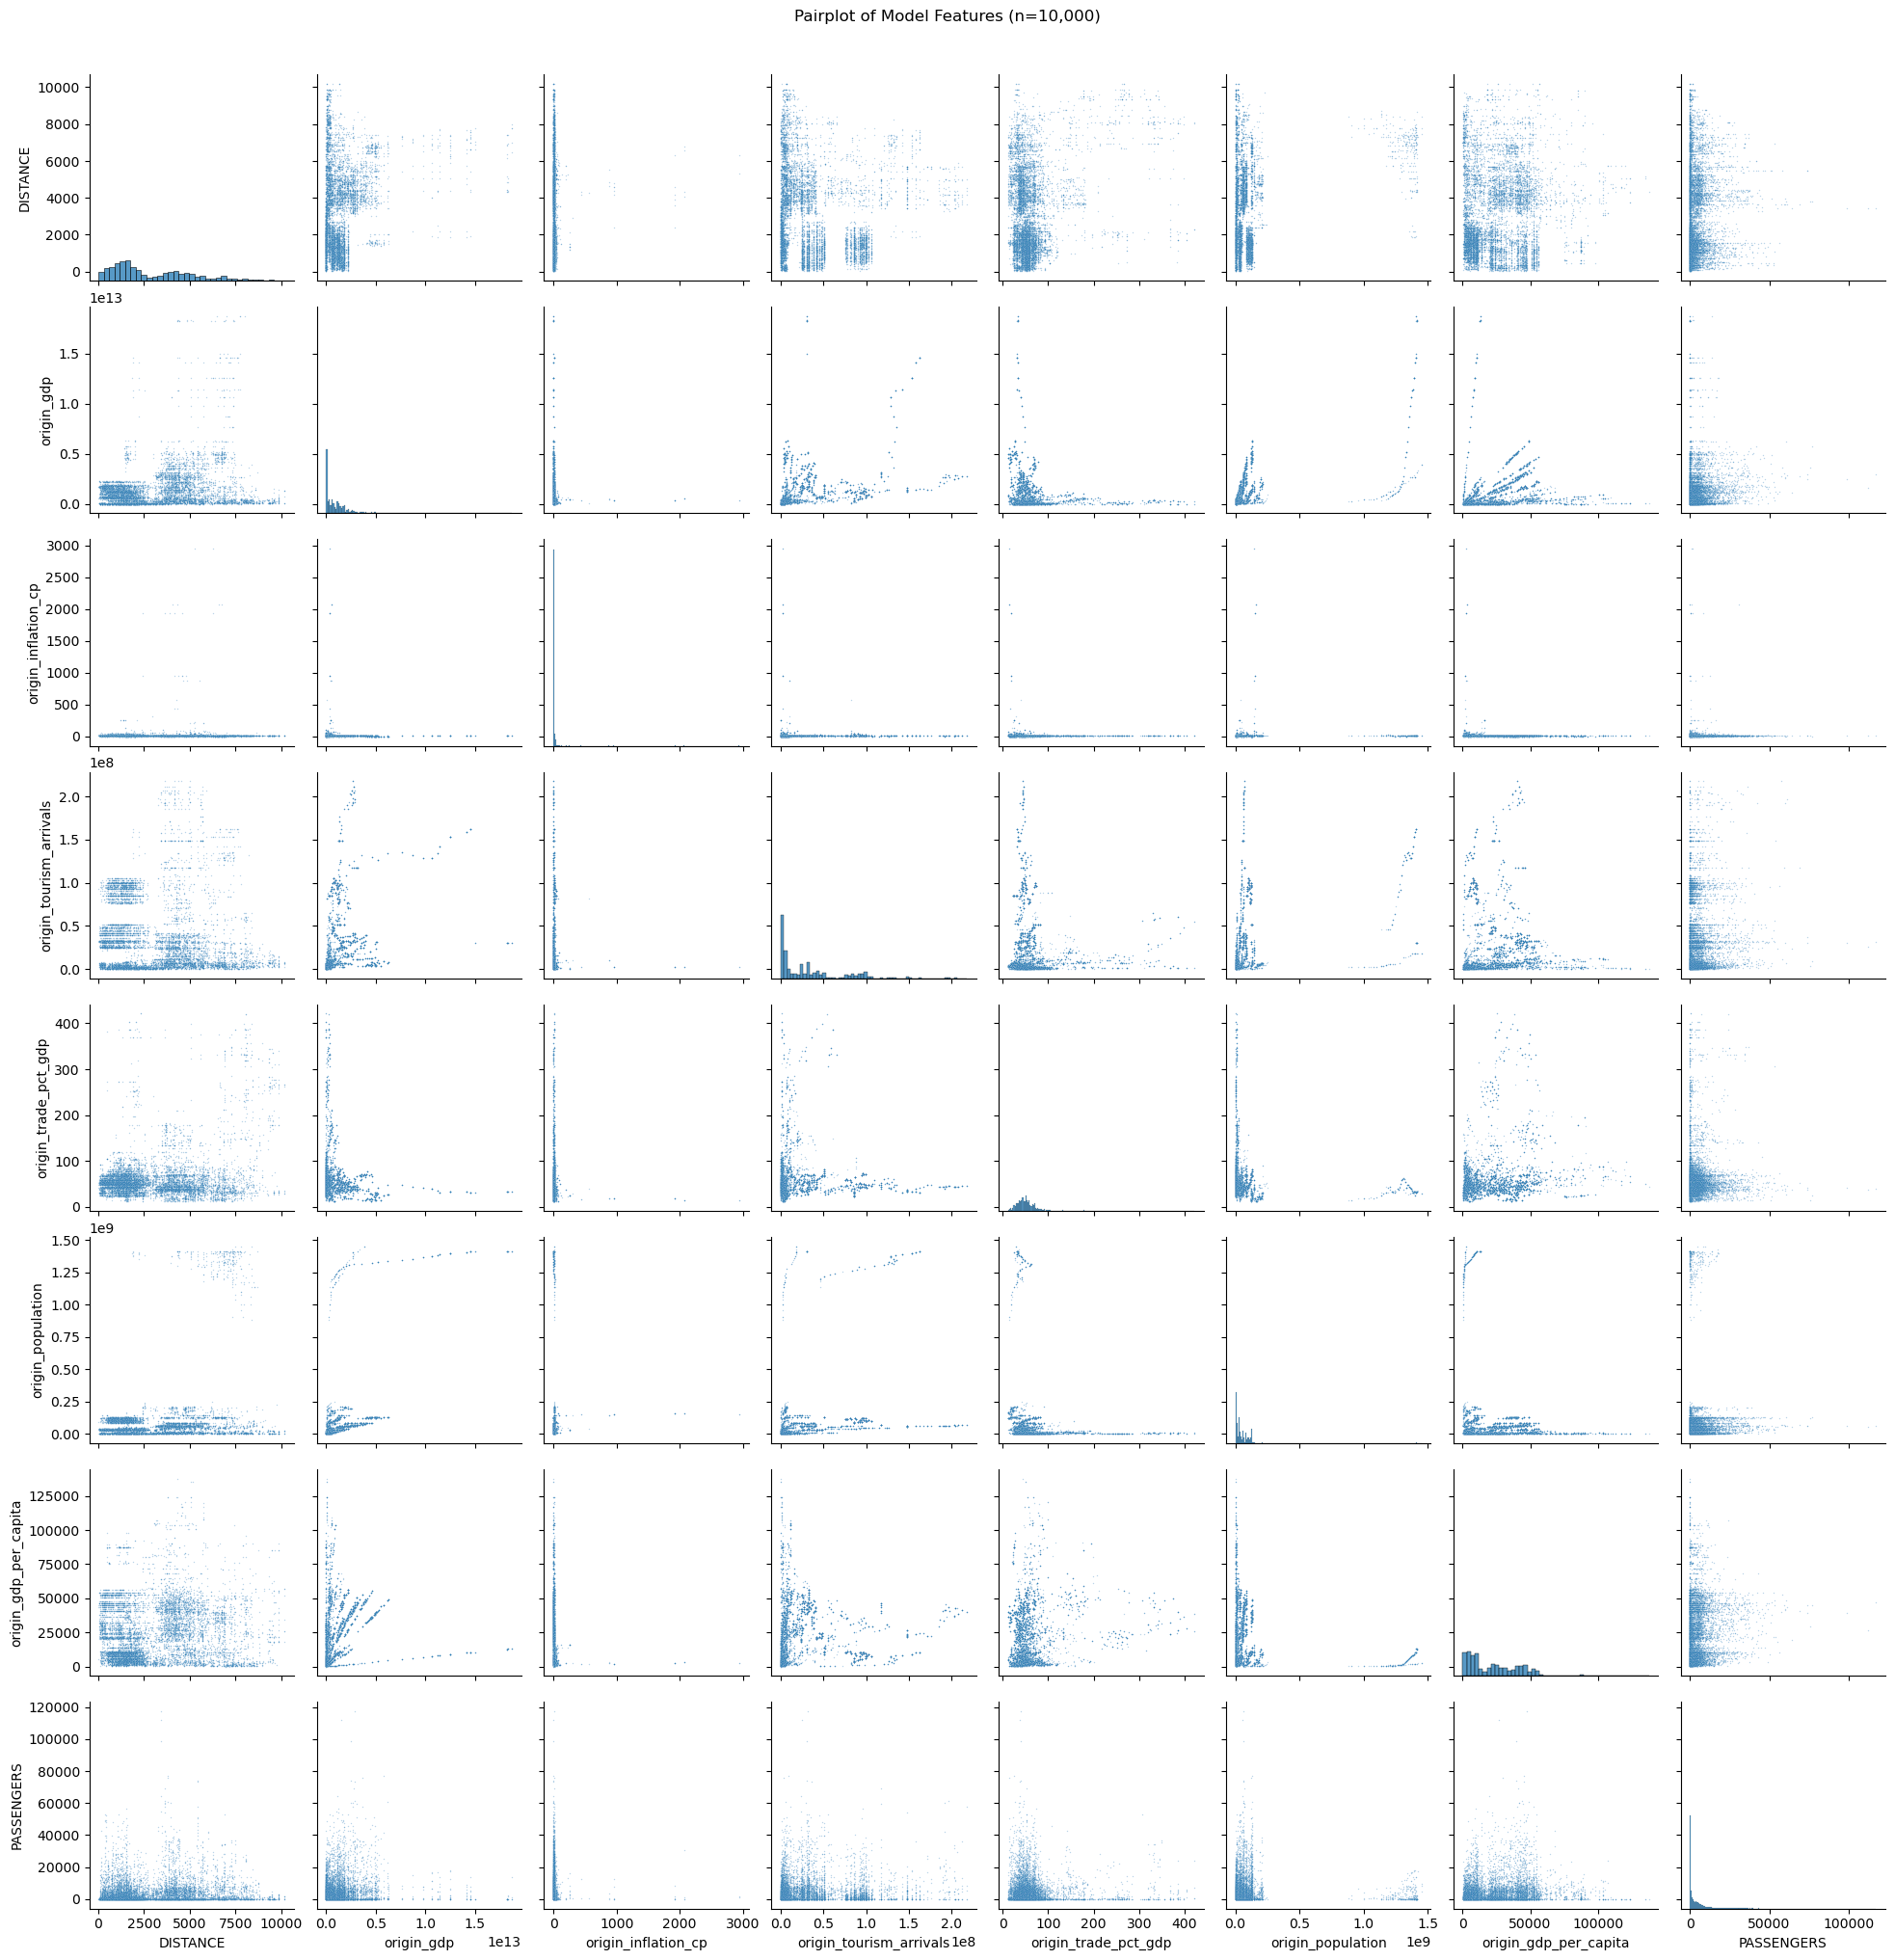

In [24]:
# Sample the data to speed up visualization
# 10,000 points is typically enough to see patterns
sample_size = min(10000, len(df_model))
df_sample = df_model.sample(n=sample_size, random_state=42)

sns.pairplot(df_sample, plot_kws={'alpha': 0.3, 's': 1})
plt.suptitle(f'Pairplot of Model Features (n={sample_size:,})', y=1.02)
plt.show()

In [33]:
df.groupby('ORIGIN', '')

,PASSENGERS,FREIGHT,MAIL,DISTANCE,UNIQUE_CARRIER,AIRLINE_ID,UNIQUE_CARRIER_NAME,UNIQUE_CARRIER_ENTITY,REGION,CARRIER,...,dest_inflation_cp,dest_gdp,dest_gdp_per_capita,dest_population,dest_tourism_arrivals,dest_trade_pct_gdp,U.S. Gulf Coast Kerosene-Type Jet Fuel Spot Price FOB (Dollars per Gallon),Travel_type,Travel_type_continent,year_month
44,0,0,0,10,YB (1),20283,Trans Continental Airlines,16903,I,YB,...,5.397956,5.963144e+12,23888.600009,249623000.0,79732000.0,15.270116,0.494,Domestic,Domestic,1990-06
45,0,0,0,10,YB (1),20283,Trans Continental Airlines,16903,I,YB,...,5.397956,5.963144e+12,23888.600009,249623000.0,79732000.0,15.270116,0.494,Domestic,Domestic,1990-06
46,0,0,0,10,YB (1),20283,Trans Continental Airlines,16903,I,YB,...,5.397956,5.963144e+12,23888.600009,249623000.0,79732000.0,15.270116,0.535,Domestic,Domestic,1990-07
47,0,0,0,11,CO,19704,Continental Air Lines Inc.,10221,P,CO,...,NaN,1.284000e+09,19227.889425,43342.0,676000.0,114.563863,0.971,Domestic,Domestic,1990-11
48,0,0,0,11,CO,19704,Continental Air Lines Inc.,10221,P,CO,...,NaN,3.394000e+09,20909.959030,138610.0,1362000.0,15.910915,0.803,Domestic,Domestic,1990-12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10179062,83663,87134,210,404,DL,19790,Delta Air Lines Inc.,01260,D,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,2.094,Domestic,Domestic,2025-06
10179063,84275,562218,5,404,DL,19790,Delta Air Lines Inc.,01260,D,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,2.069,Domestic,Domestic,2025-03
10179064,84832,204449,0,404,DL,19790,Delta Air Lines Inc.,01260,D,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,2.069,Domestic,Domestic,2025-03
10179065,86078,58485,0,404,DL,19790,Delta Air Lines Inc.,01260,D,DL,...,NaN,NaN,NaN,NaN,NaN,NaN,1.928,Domestic,Domestic,2025-05


In [18]:
X = df_model.drop(target_col, axis=1)
y = df_model[target_col]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. Build Pipeline ---
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    # handle_unknown='ignore' is crucial for Carriers that might only appear in test set
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore')) 
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# The Model
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [19]:
# --- 5. Train & Evaluate ---
print("--- Training Linear Regression... ---")
lr_pipeline.fit(X_train, y_train)

print("\n--- Evaluation Results ---")
preds = lr_pipeline.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"R-squared: {r2:.2%}")
print(f"RMSE: {rmse:,.0f} passengers per route/month")

# --- 6. Interpret Coefficients (The "Why") ---
# This part extracts the weights the model assigned to each feature
feature_names = (numerical_features + 
                 list(lr_pipeline.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

coefs = lr_pipeline.named_steps['regressor'].coef_

df_coefs = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
df_coefs['Abs_Coefficient'] = df_coefs['Coefficient'].abs()
print("\n--- Top 10 Drivers of Inbound Passenger Volume ---")
print(df_coefs.sort_values(by='Abs_Coefficient', ascending=False).head(10))

--- Training Linear Regression... ---

--- Evaluation Results ---
R-squared: 2.90%
RMSE: 3,681 passengers per route/month


NotFittedError: This OneHotEncoder instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

--- Generating Plots ---


/tmp/ipykernel_8636/3321022863.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_coefs, x='Coefficient', y='Feature', palette='viridis', ax=axes[2])


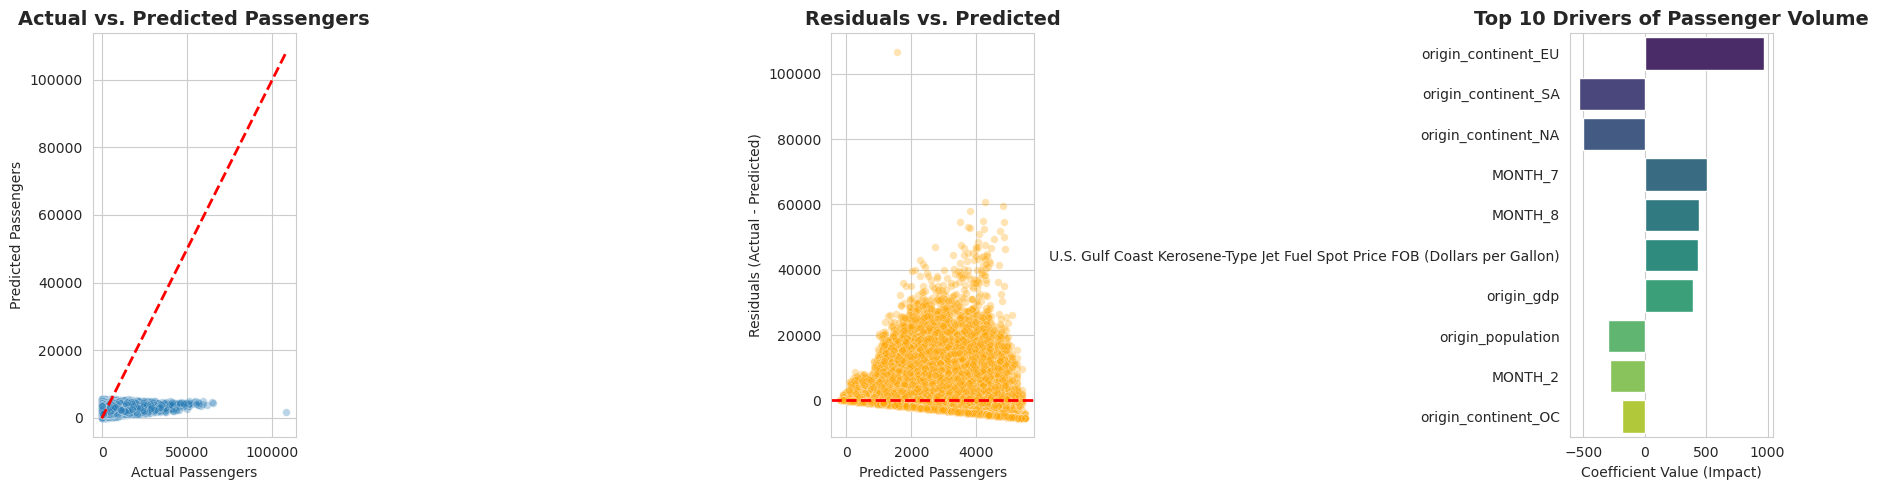

In [ ]:
# --- 6. PLOTTING ---
print("--- Generating Plots ---")
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Actual vs Predicted
# Ideally, all points lie on the red dashed line
sns.scatterplot(x=y_test, y=preds, alpha=0.3, s=30, ax=axes[0])
min_val = min(y_test.min(), preds.min())
max_val = max(y_test.max(), preds.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
axes[0].set_title("Actual vs. Predicted Passengers", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Actual Passengers")
axes[0].set_ylabel("Predicted Passengers")

# Plot 2: Residuals vs Predicted
# We want a random cloud centered on 0. Patterns here indicate missing non-linear features.
residuals = y_test - preds
sns.scatterplot(x=preds, y=residuals, alpha=0.3, s=30, color='orange', ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_title("Residuals vs. Predicted", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Predicted Passengers")
axes[1].set_ylabel("Residuals (Actual - Predicted)")

# Plot 3: Top Feature Coefficients
# Extract feature names from the pipeline
feature_names = (numerical_features + 
                 list(lr_pipeline.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))
coefs = lr_pipeline.named_steps['regressor'].coef_
df_coefs = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
df_coefs['Abs_Coefficient'] = df_coefs['Coefficient'].abs()

# Sort by absolute impact
top_coefs = df_coefs.sort_values(by='Abs_Coefficient', ascending=False).head(10)

sns.barplot(data=top_coefs, x='Coefficient', y='Feature', palette='viridis', ax=axes[2])
axes[2].set_title("Top 10 Drivers of Passenger Volume", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Coefficient Value (Impact)")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()